In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Instagram 다운로드 & 비디오 처리 & Gemini LMM
!pip install -q instaloader yt-dlp
!pip install -q google-generativeai
!pip install -q opencv-python-headless pillow numpy matplotlib
!pip install -q scikit-image tqdm

print('✅ 설치 완료')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 78.1 MB/s eta 0:00:00
✅ 설치 완료


In [3]:
import os, cv2, json, time, base64
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import rcParams
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from IPython.display import display, Markdown, HTML
import google.generativeai as genai

# 한글 폰트 설치
!apt-get -qq install -y fonts-nanum > /dev/null
import matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    rcParams['font.family'] = 'NanumGothic'
rcParams['axes.unicode_minus'] = False

# 작업 디렉토리
BASE_DIR = Path('/content/drive/MyDrive/github/ai_video_detection')
VIDEOS_DIR = BASE_DIR / 'videos'
FRAMES_DIR = BASE_DIR / 'frames'
OUTPUT_DIR = BASE_DIR / 'outputs'
for d in [VIDEOS_DIR, FRAMES_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('✅ 환경 준비 완료')

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


✅ 환경 준비 완료


## 2️⃣ Gemini API 키 설정
Google AI Studio에서 무료 API 키 발급 → Colab의 🔑 아이콘으로 GEMINI_API_KEY 저장


In [4]:
from google.colab import userdata
import getpass

try:
    GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
except Exception:
    GOOGLE_API_KEY = getpass.getpass('🔑 Gemini API 키를 입력하세요: ')

genai.configure(api_key=GOOGLE_API_KEY)

model = genai.GenerativeModel(
    model_name='gemini-3.1-flash-lite-preview',
    generation_config={
        'temperature': 0.2,
        'top_p': 0.9,
        'max_output_tokens': 2048,
    },
    safety_settings=[
        {'category': c, 'threshold': 'BLOCK_NONE'}
        for c in ['HARM_CATEGORY_HARASSMENT','HARM_CATEGORY_HATE_SPEECH',
                  'HARM_CATEGORY_SEXUALLY_EXPLICIT','HARM_CATEGORY_DANGEROUS_CONTENT']
    ]
)
print('✅ gemini-3.1-flash-lite-preview 로드 완료')

✅ gemini-3.1-flash-lite-preview 로드 완료


## 3️⃣ Instagram 영상 수집 (해시태그 기반)


In [5]:
from google.colab import files
import shutil, os

print('📤 instagram_cookies.txt 업로드')
uploaded = files.upload()

COOKIE_PATH = '/content/drive/MyDrive/github/instagram_cookies.txt'
src = list(uploaded.keys())[0]
shutil.copy(src, COOKIE_PATH)

with open(COOKIE_PATH) as f:
    c = f.read()
print('✅ sessionid 발견' if 'sessionid' in c else '❌ sessionid 없음 — 재로그인 필요')

📤 instagram_cookies.txt 업로드


Saving instagram_cookies.txt to instagram_cookies.txt
✅ sessionid 발견


In [6]:
# === 🎯 Instagram 영상 다운로드 (yt-dlp + 쿠키) ===
import os, time

# 분석할 Instagram URL들 (앱/웹에서 '⋯' → '링크 복사'로 수집)
SINGLE_URLS = [
    'https://www.instagram.com/p/DWzBYuViZ1v/',
    'https://www.instagram.com/p/DW9J3eDgbsh/',
    'https://www.instagram.com/p/DXB0bwtiUV9/',
    'https://www.instagram.com/p/DXHhIhEifBP/',
    'https://www.instagram.com/p/DW38xgcCVln/',
    'https://www.instagram.com/p/DXOMFjxiTA3/',
    'https://www.instagram.com/p/DXO_GzTCRIK/',
    'https://www.instagram.com/p/DXWKYjQib-z/',
    'https://www.instagram.com/p/DXI6BG0CSHy/',
    'https://www.instagram.com/reels/DWEeptIDwJT/',
    'https://www.instagram.com/reels/DUZlBe6Ekkr/',
    'https://www.instagram.com/reels/DLRWOpnPfVX/',
    'https://www.instagram.com/p/DXO2CzaAIWR/',
    'https://www.instagram.com/p/DVxMvXcifmE/',
    'https://www.instagram.com/p/DQJa9D3CZrc/',
    'https://www.instagram.com/p/DWLuSyIkhMV/',
    'https://www.instagram.com/p/DVzVq5ND3lg/',
    'https://www.instagram.com/p/DW_HNH7gFVr/',
    'https://www.instagram.com/p/DSv0eT5Agk-/',
    'https://www.instagram.com/p/DRYfSidEYX5/',
    'https://www.instagram.com/p/DWks41KCQLf/',
    'https://www.instagram.com/p/DUiDSdWCNMX/',
    'https://www.instagram.com/p/DUN9-ZGEbHh/',
    'https://www.instagram.com/p/DXeZLPRjl5k/',
'https://www.instagram.com/p/DXdotCVjh3Y/',
'https://www.instagram.com/p/DXoT_sEDuGm/',
'https://www.instagram.com/p/DXoTcfPjs7P/',
'https://www.instagram.com/p/DXdOvulDhSS/',
'https://www.instagram.com/p/DXfkP59DvKA/',
'https://www.instagram.com/p/DV6JvL5E-Eb/',
'https://www.instagram.com/p/DXES5ivj1Ee/',
'https://www.instagram.com/p/DQfINMOESwD/',
'https://www.instagram.com/p/DWdztGKjd3K/',
'https://www.instagram.com/p/DXCGiTrD2hA/',
'https://www.instagram.com/p/DUSzr3pkT-b/',
'https://www.instagram.com/p/DTuqBWzEUQQ/',
'https://www.instagram.com/p/DRX1v7fE4vH/',
'https://www.instagram.com/p/DV589YvDFNC/',
'https://www.instagram.com/p/DTfeHKrieaC/',
'https://www.instagram.com/p/DMh2ksdyr1_/',
'https://www.instagram.com/p/DWM4PSAgDlZ/',
'https://www.instagram.com/p/DNEI4GkTO71/',
'https://www.instagram.com/p/DTzdz9FklgB/',
'https://www.instagram.com/p/DNonIy3Tu_6/',
'https://www.instagram.com/p/CZORV9VsHq7/',
'https://www.instagram.com/p/DLW_MvyShjh/',
'https://www.instagram.com/p/DRv3nhTEit8/',
'https://www.instagram.com/p/DVL1hpZkgwB/',
'https://www.instagram.com/p/DUXrg9IEkCo/',
'https://www.instagram.com/p/DUppWMzkqef/',
'https://www.instagram.com/p/DUnSGWgEnSj/',
'https://www.instagram.com/p/DPx51dMEX1U/',
'https://www.instagram.com/p/DXL2Gt2ESHs/',
'https://www.instagram.com/reel/DUZlBe6Ekkr/',
'https://www.instagram.com/reel/DLlr7L1yN-E/',
'https://www.instagram.com/p/DTIQHRJDzDd/',
'https://www.instagram.com/p/DXES5ivj1Ee/',
'https://www.instagram.com/p/DWGWXObFCPq/',
'https://www.instagram.com/p/DKzd005vsrZ/',
'https://www.instagram.com/p/DWn5xQPE7PD/',
'https://www.instagram.com/p/DUilqRDkeGL/',
'https://www.instagram.com/p/DLRWOpnPfVX/',
'https://www.instagram.com/p/DT-VP3KEjvS/',
'https://www.instagram.com/p/DVLpDMRk9Vu/',
'https://www.instagram.com/p/DMh2ksdyr1_/',
'https://www.instagram.com/p/DSKVG9cCbkD/',
'https://www.instagram.com/p/DUqlxgTDAuT/',
'https://www.instagram.com/p/DUqlxgTDAuT/',
'https://www.instagram.com/p/DV21KvbDKGn/',
'https://www.instagram.com/p/DXjuOOzEhM1/',
'https://www.instagram.com/p/DNSSSi_tOIr/',
'https://www.instagram.com/p/DUAoHcOCAIk/',
'https://www.instagram.com/p/DR7VHIFD5vp/',
'https://www.instagram.com/p/DWizauGkhKW/',
'https://www.instagram.com/p/DU-To2JkYAX/',
'https://www.instagram.com/p/DPh8Xxjk6yb/',
'https://www.instagram.com/p/DP6hZmCiPzn/',
'https://www.instagram.com/p/DPY81nVgV5C/',
'https://www.instagram.com/p/DPXx3fzAVRy/',
'https://www.instagram.com/p/DRsoHLUE04H/',
'https://www.instagram.com/p/DUDsrY4iPQR/',
'https://www.instagram.com/p/DTmu_fIjDYh/',
'https://www.instagram.com/p/DRQaPmikifk/',
'https://www.instagram.com/p/DVww7KKCRHi/',
'https://www.instagram.com/p/DUG6bWTCJJs/',
'https://www.instagram.com/p/DVf9RdJDL_i/',
'https://www.instagram.com/reel/DWyrlt8j1Mv/?utm_source=ig_web_copy_link&igsh=MzRlODBiNWFlZA==',
'https://www.instagram.com/reel/DUilqRDkeGL/?utm_source=ig_web_copy_link&igsh=MzRlODBiNWFlZA==',
'https://www.instagram.com/reel/DXJmL7Qkn-L/?utm_source=ig_web_copy_link&igsh=MzRlODBiNWFlZA==',
'https://www.instagram.com/reel/DTiRdF0j9wQ/?utm_source=ig_web_copy_link&igsh=MzRlODBiNWFlZA==',
'https://www.instagram.com/reel/DV99e8dEky1/?utm_source=ig_web_copy_link&igsh=MzRlODBiNWFlZA==',
'https://www.instagram.com/reel/DWgPQ86kS0T/?utm_source=ig_web_copy_link&igsh=MzRlODBiNWFlZA==',
'https://www.instagram.com/reel/DTkNf4VkVk7/?utm_source=ig_web_copy_link&igsh=MzRlODBiNWFlZA==',
'https://www.instagram.com/reel/DTReMMLk4jB/?utm_source=ig_web_copy_link&igsh=MzRlODBiNWFlZA==',
'https://www.instagram.com/reel/DS7WLZ3iF0D/?utm_source=ig_web_copy_link&igsh=MzRlODBiNWFlZA==',
'https://www.instagram.com/reel/DWGkWPsE1HU/?utm_source=ig_web_copy_link&igsh=MzRlODBiNWFlZA==',
'https://www.instagram.com/reel/DV_XJYTEtrP/?utm_source=ig_web_copy_link&igsh=MzRlODBiNWFlZA==',
'https://www.instagram.com/reel/DXMOPujiTi3/?utm_source=ig_web_copy_link&igsh=MzRlODBiNWFlZA==',
'https://www.instagram.com/reel/DWWNuxykfMp/?utm_source=ig_web_copy_link&igsh=MzRlODBiNWFlZA==',
'https://www.instagram.com/reel/CzfVIZgRYjA/?utm_source=ig_web_copy_link&igsh=MzRlODBiNWFlZA==',
'https://www.instagram.com/reel/DWV0SyEkT-5/?utm_source=ig_web_copy_link&igsh=MzRlODBiNWFlZA==',
'https://www.instagram.com/reel/DWXzIBIEpug/?utm_source=ig_web_copy_link&igsh=MzRlODBiNWFlZA==',
'https://www.instagram.com/reel/DOOawUVCPP_/?utm_source=ig_web_copy_link&igsh=MzRlODBiNWFlZA==',
'https://www.instagram.com/reel/DXIAHChlbar/?utm_source=ig_web_copy_link&igsh=MzRlODBiNWFlZA==',
'https://www.instagram.com/reel/DUYNH-QCPvD/?utm_source=ig_web_copy_link&igsh=MzRlODBiNWFlZA==',

    # 필요한 만큼 추가 (3~10개 권장)
]

COOKIE_PATH = '/content/drive/MyDrive/github/instagram_cookies.txt'
assert os.path.exists(COOKIE_PATH), '❌ 쿠키 파일이 없습니다. 먼저 쿠키 업로드 셀을 실행하세요'

success, failed = 0, 0
for url in SINGLE_URLS:
    print(f'⬇️  {url}')
    ret = os.system(
        f'yt-dlp --cookies "{COOKIE_PATH}" '
        f'--no-warnings --quiet '
        f'-o "{VIDEOS_DIR}/%(id)s.%(ext)s" "{url}"'
    )
    if ret == 0:
        success += 1
        print('   ✅ 성공')
    else:
        failed += 1
        print('   ❌ 실패')
    time.sleep(2)

video_files = list(VIDEOS_DIR.rglob('*.mp4'))
print(f'\n━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'✅ 성공 {success}개 · ❌ 실패 {failed}개')
print(f'📹 총 {len(video_files)}개 .mp4 파일')
for v in video_files: print(' •', v.name)

⬇️  https://www.instagram.com/p/DWzBYuViZ1v/
   ✅ 성공
⬇️  https://www.instagram.com/p/DW9J3eDgbsh/
   ✅ 성공
⬇️  https://www.instagram.com/p/DXB0bwtiUV9/
   ✅ 성공
⬇️  https://www.instagram.com/p/DXHhIhEifBP/
   ✅ 성공
⬇️  https://www.instagram.com/p/DW38xgcCVln/
   ✅ 성공
⬇️  https://www.instagram.com/p/DXOMFjxiTA3/
   ✅ 성공
⬇️  https://www.instagram.com/p/DXO_GzTCRIK/
   ✅ 성공
⬇️  https://www.instagram.com/p/DXWKYjQib-z/
   ✅ 성공
⬇️  https://www.instagram.com/p/DXI6BG0CSHy/
   ✅ 성공
⬇️  https://www.instagram.com/reels/DWEeptIDwJT/
   ✅ 성공
⬇️  https://www.instagram.com/reels/DUZlBe6Ekkr/
   ✅ 성공
⬇️  https://www.instagram.com/reels/DLRWOpnPfVX/
   ✅ 성공
⬇️  https://www.instagram.com/p/DXO2CzaAIWR/
   ✅ 성공
⬇️  https://www.instagram.com/p/DVxMvXcifmE/
   ✅ 성공
⬇️  https://www.instagram.com/p/DQJa9D3CZrc/
   ✅ 성공
⬇️  https://www.instagram.com/p/DWLuSyIkhMV/
   ✅ 성공
⬇️  https://www.instagram.com/p/DVzVq5ND3lg/
   ✅ 성공
⬇️  https://www.instagram.com/p/DW_HNH7gFVr/
   ✅ 성공
⬇️  https://www.instagram.com/p/DS

# =============================================================
# Instagram 영상 AI 판독 - 워터마크/서명 사전 필터 (Pre-filter)
# Google Colab 노트북에 셀 단위로 복사해서 사용
# =============================================================
# 사용 흐름:
#   1) [CELL A] 라이브러리 설치
#   2) [CELL B] 검사 함수 정의
#   3) [CELL C] 통합 실행 - run_all_watermark_checks(video_path)
#   4) verdict["ai_watermark_found"] == True 면 1차에서 AI로 판정
#      False 면 그제서야 기존의 AI 분류 모델 단계로 넘김
# =============================================================

# ============================================================
# [CELL A] 라이브러리 설치 (한 번만 실행)
# ============================================================

In [7]:
!pip install -q c2pa-python Pillow opencv-python-headless numpy pytesseract transformers torch torchaudio audioseal
!apt-get -qq install -y exiftool tesseract-ocr ffmpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.3/63.3 kB 6.1 MB/s eta 0:00:00
Selecting previously unselected package libarchive-zip-perl.
(Reading database ... 122378 files and directories currently installed.)
Preparing to unpack .../libarchive-zip-perl_1.68-1_all.deb ...
Unpacking libarchive-zip-perl (1.68-1) ...
Selecting previously unselected package libimage-exiftool-perl.
Preparing to unpack .../libimage-exiftool-perl_12.40+dfsg-1_all.deb ...
Unpacking libimage-exiftool-perl (12.40+dfsg-1) ...
Selecting previously unselected package libmime-charset-perl.
Preparing to unpack .../libmime-charset-perl_1.012.2-1_all.deb ...
Unpacking libmime-charset-perl (1.012.2-1) ...
Selecting previously unselected package libsombok3:amd64.
Preparing to unpack .../libsombok3_2.4.0-2_amd64.deb ...
Unpacking libsombok3:amd64 (2.4.0-2) ...
Selecting previously unselected package libunicode-linebreak-perl.
Preparing to unp

# ============================================================
# [CELL B] 워터마크 / 서명 검사 함수 정의
# ============================================================

## 4️⃣ 비디오 키프레임 추출
장면 변화(SSIM) + 균등 간격 혼합 샘플링

In [8]:
from skimage.metrics import structural_similarity as ssim

def extract_keyframes(video_path, num_frames=10, scene_threshold=0.55):
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total == 0:
        cap.release(); return []

    uniform_idx = np.linspace(0, total - 1, num=num_frames * 2, dtype=int)
    candidates = []
    prev_gray = None
    for idx in uniform_idx:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ok, frame = cap.read()
        if not ok: continue
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray_small = cv2.resize(gray, (160, 90))
        score = 1.0
        if prev_gray is not None:
            score = 1.0 - ssim(prev_gray, gray_small)
        candidates.append({
            'idx': idx, 'ts': idx / fps,
            'frame': cv2.cvtColor(frame, cv2.COLOR_BGR2RGB),
            'change': score
        })
        prev_gray = gray_small
    cap.release()

    candidates.sort(key=lambda x: -x['change'])
    top_change = candidates[:num_frames]
    top_change.sort(key=lambda x: x['ts'])
    return [(c['ts'], c['frame']) for c in top_change]

def save_frames(video_path, frames, out_dir):
    out_dir = Path(out_dir) / Path(video_path).stem
    out_dir.mkdir(parents=True, exist_ok=True)
    paths = []
    for i, (ts, fr) in enumerate(frames):
        p = out_dir / f'f{i:02d}_t{ts:.2f}s.jpg'
        Image.fromarray(fr).save(p, quality=90)
        paths.append((ts, p))
    return paths

video_files = list(VIDEOS_DIR.rglob('*.mp4'))
all_frames = {}
for vp in tqdm(video_files, desc='키프레임 추출'):
    frames = extract_keyframes(vp, num_frames=10)
    saved = save_frames(vp, frames, FRAMES_DIR)
    all_frames[str(vp)] = saved
    print(f'  • {vp.name}: {len(saved)}프레임')

print(f'\n✅ {len(all_frames)}개 영상 프레임 추출 완료')

키프레임 추출:   1%|          | 1/108 [00:21<38:23, 21.52s/it]

  • DWzBYuViZ1v.mp4: 10프레임


키프레임 추출:   2%|▏         | 2/108 [00:40<35:12, 19.93s/it]

  • DW9J3eDgbsh.mp4: 10프레임


키프레임 추출:   3%|▎         | 3/108 [00:56<31:42, 18.12s/it]

...

  • DXIAHChlbar.mp4: 10프레임


키프레임 추출:  99%|█████████▉| 107/108 [19:10<00:10, 10.24s/it]

  • DUYNH-QCPvD.mp4: 10프레임


키프레임 추출: 100%|██████████| 108/108 [19:19<00:00, 10.74s/it]

  • DXL2Gt2ESHs.mp4: 10프레임

✅ 108개 영상 프레임 추출 완료


In [9]:
import os, json, subprocess, glob
import cv2
import numpy as np
from PIL import Image
from pathlib import Path


# ---------- 1. C2PA Content Credentials ----------
def check_c2pa(file_path):
    res = {"name": "C2PA", "detected": False}
    try:
        from c2pa import Reader
        ext = file_path.lower().split(".")[-1]
        mime = {"mp4":"video/mp4","mov":"video/quicktime",
                "jpg":"image/jpeg","jpeg":"image/jpeg",
                "png":"image/png","webp":"image/webp"}.get(ext,"application/octet-stream")
        with open(file_path, "rb") as f:
            mj = Reader(mime, f).json()
        if mj and mj.strip() not in ("", "{}", "null"):
            data = json.loads(mj)
            res["detected"] = True
            res["details"] = data
            blob = json.dumps(data).lower()
            res["ai_generated"] = any(k in blob for k in
                ["trainedalgorithmic","ai_generated","generative","dall-e","dalle",
                 "firefly","sora","stable diffusion","midjourney","gemini","imagen","veo"])
    except Exception as e:
        res["error"] = str(e)
    return res


# ---------- 2. EXIF / XMP / IPTC 메타데이터 ----------
def check_metadata(file_path):
    res = {"name":"Metadata(EXIF/XMP/IPTC)","detected":False,"ai_indicators":[]}
    try:
        out = subprocess.run(["exiftool","-j","-G",file_path],
                             capture_output=True, text=True, timeout=30)
        meta = json.loads(out.stdout)[0] if out.stdout.strip() else {}
        blob = json.dumps(meta).lower()
        for s in ["trainedalgorithmicmedia","compositewithtrainedalgorithmic",
                  "ai-generated","ai generated","generated by ai",
                  "dall-e","dalle","midjourney","stable diffusion","sdxl",
                  "firefly","comfyui","automatic1111","invokeai",
                  "runway","pika","sora","gemini","imagen","veo",
                  "kling","luma","synthid"]:
            if s in blob: res["ai_indicators"].append(s)
        res["detected"] = len(res["ai_indicators"]) > 0
    except Exception as e:
        res["error"] = str(e)
    return res


# ---------- 3. DALL-E 2 가시 컬러바 ----------
def check_dalle2_signature(image_path):
    res = {"name":"DALL-E 2 visible watermark","detected":False}
    img = cv2.imread(image_path)
    if img is None: return res
    h, w = img.shape[:2]
    crop = img[int(h*0.94):h, int(w*0.86):w]
    if crop.size == 0: return res
    rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    expected = [(245,205,80),(70,180,180),(150,200,90),(220,80,70),(40,60,100)]
    parts = np.array_split(rgb, 5, axis=1)
    matches = sum(1 for p,e in zip(parts,expected)
                  if np.linalg.norm(p.mean(axis=(0,1)) - np.array(e)) < 80)
    res["matches"] = matches
    res["detected"] = matches >= 4
    return res


# ---------- 4. Meta AudioSeal (오디오) ----------
def check_audioseal(video_path):
    res = {"name":"Meta AudioSeal","detected":False}
    try:
        import torch, torchaudio
        from audioseal import AudioSeal
        wav_path = "/tmp/_audioseal.wav"
        subprocess.run(["ffmpeg","-y","-i",video_path,"-ac","1","-ar","16000",wav_path],
                       capture_output=True)
        if not os.path.exists(wav_path):
            res["error"] = "오디오 추출 실패"; return res
        wav, sr = torchaudio.load(wav_path)
        if wav.dim() == 2: wav = wav.unsqueeze(0)
        det = AudioSeal.load_detector("audioseal_detector_16bits")
        with torch.no_grad():
            out, _ = det(wav, sr)
        prob = float(out[:,1,:].mean().item())
        res["watermark_probability"] = prob
        res["detected"] = prob > 0.5
    except Exception as e:
        res["error"] = str(e)
    return res


# ---------- 5. Meta VideoSeal (영상) ----------
def check_videoseal(video_path):
    res = {"name":"Meta VideoSeal","detected":False}
    try:
        import torch, torchvision
        from videoseal.evals.full import setup_model_from_model_card

        video, _, _ = torchvision.io.read_video(video_path, pts_unit="sec")
        if video.shape[0] == 0:
            res["error"] = "영상 디코딩 실패"; return res
        # (T,H,W,C) -> (T,C,H,W), 0-1 정규화, 처음 32프레임만
        video = video.permute(0, 3, 1, 2).float() / 255.0
        if video.shape[0] > 32:
            video = video[:32]
        model = setup_model_from_model_card("videoseal_1.0")
        model.eval()
        with torch.no_grad():
            outputs = model.detect(video.unsqueeze(0))
        prob = float(outputs["preds"].sigmoid().mean().item())
        res["watermark_probability"] = prob
        res["detected"] = prob > 0.5
    except Exception as e:
        res["error"] = str(e)
    return res


# ---------- 6. Stability AI invisible-watermark (이미지/SD 1.x/2.x) ----------
def check_stability_invisible_watermark(image_path):
    res = {"name":"Stability AI invisible-watermark","detected":False}
    try:
        from imwatermark import WatermarkDecoder
        bgr = cv2.imread(image_path)
        if bgr is None: return res
        # SD 가 박는 페이로드 후보들
        for nbits in (136, 32, 48):  # 17byte("StableDiffusionV1"), 32bit, 48bit
            try:
                dec = WatermarkDecoder("bytes", nbits)
                wm = dec.decode(bgr, "dwtDct")
                if wm is None: continue
                text = wm.decode("utf-8", errors="ignore")
                if any(s in text for s in ["StableDiffusion","SDV","SDXL"]):
                    res["detected"] = True
                    res["payload"] = text
                    break
            except Exception:
                continue
    except Exception as e:
        res["error"] = str(e)
    return res


# ---------- 7~9. 검사 불가 placeholder ----------
def check_synthid(file_path):
    return {"name":"Google SynthID","detected":None,
            "note":"공개 SDK 없음 - Vertex AI / synthid.google 만 가능"}

def check_stable_signature(file_path):
    return {"name":"Meta Stable Signature","detected":None,
            "note":"모델별 비밀키 필요 - 외부 검출 불가"}

def check_treering(file_path):
    return {"name":"Tree-Ring / Gaussian Shading","detected":None,
            "note":"원본 시드/키 필요 - 외부 검출 불가"}


print("[OK] 셀 B - 워터마크 검사 함수 정의 완료")

[OK] 셀 B - 워터마크 검사 함수 정의 완료


# ============================================================
# [CELL C] 통합 실행 - 영상 1개에 대해 전체 검사
# ============================================================

In [10]:
def check_video_watermarks(video_path, frame_paths):
    """
    video_path  : 영상 파일 경로 (Path 또는 str)
    frame_paths : [(ts, Path), ...]  - 키프레임 추출 셀의 결과
    """
    video_path = str(video_path)
    print(f"\n[검사] {Path(video_path).name}  (키프레임 {len(frame_paths)}장)")

    # --- 영상 단위 검사 (영상 파일 통째로 봐야 하는 것) ---
    file_level = [
        check_c2pa(video_path),
        check_metadata(video_path),
        check_audioseal(video_path),
        check_videoseal(video_path),
        check_synthid(video_path),
        check_stable_signature(video_path),
        check_treering(video_path),
    ]

    # --- 프레임 단위 검사 (이미지 시그니처) ---
    frame_level = []
    for ts, fp in frame_paths:
        fp_str = str(fp)
        frame_level.append({
            "frame": fp_str, "ts": ts,
            "checks": [
                check_c2pa(fp_str),
                check_metadata(fp_str),
                check_dalle2_signature(fp_str),
                check_stability_invisible_watermark(fp_str),
            ],
        })

    # --- 종합 ---
    detected, inconclusive = [], []
    for r in file_level:
        if r.get("detected") is True: detected.append(r["name"])
        elif r.get("detected") is None: inconclusive.append(r["name"])
    for fr in frame_level:
        for c in fr["checks"]:
            if c.get("detected") is True and c["name"] not in detected:
                detected.append(c["name"])

    verdict = {
        "video": video_path,
        "ai_watermark_found": len(detected) > 0,
        "methods_triggered": detected,
        "inconclusive_methods": list(set(inconclusive)),
        "file_level_results": file_level,
        "frame_level_results": frame_level,
    }

    print(f"  AI 워터마크 검출: {verdict['ai_watermark_found']}")
    print(f"  검출된 방식    : {detected if detected else '없음'}")
    for r in file_level:
        line = f"    - {r['name']:32s} detected={r.get('detected')}"
        if r.get("error"): line += f"  err={r['error'][:60]}"
        if r.get("ai_indicators"): line += f"  hits={r['ai_indicators']}"
        if r.get("watermark_probability") is not None:
            line += f"  prob={r['watermark_probability']:.3f}"
        print(line)
    return verdict


# 셀 B 함수 점검
required = ["check_c2pa","check_metadata","check_dalle2_signature",
            "check_audioseal","check_videoseal",
            "check_stability_invisible_watermark",
            "check_synthid","check_stable_signature","check_treering"]
missing = [n for n in required if n not in globals()]
if missing:
    print("[!] 셀 B 함수 누락:", missing); raise SystemExit
if "all_frames" not in globals() or not all_frames:
    print("[!] all_frames 가 없어. 키프레임 추출 셀 먼저 실행."); raise SystemExit


# 모든 영상 일괄 검사
all_verdicts = {}
for vp_str, frames_list in all_frames.items():
    if not frames_list:
        print(f"\n[skip] {vp_str} - 추출 프레임 없음")
        continue
    all_verdicts[vp_str] = check_video_watermarks(vp_str, frames_list)


# 워터마크 검출 / 통과 분리
ai_video_paths    = [vp for vp, v in all_verdicts.items() if v["ai_watermark_found"]]
clean_video_paths = [vp for vp, v in all_verdicts.items() if not v["ai_watermark_found"]]

# Gemini 입력은 통과한 영상 키프레임만
all_frames_for_gemini = {vp: all_frames[vp] for vp in clean_video_paths}

print("\n" + "=" * 60)
print("워터마크 1차 판정 요약")
print("=" * 60)
print(f"\n[워터마크 검출 - Gemini 스킵] {len(ai_video_paths)}개")
for vp in ai_video_paths:
    print(f"  - {Path(vp).name}  →  {all_verdicts[vp]['methods_triggered']}")
print(f"\n[워터마크 통과 - Gemini 분석 대상] {len(clean_video_paths)}개")
for vp in clean_video_paths:
    print(f"  - {Path(vp).name}")


[검사] DWzBYuViZ1v.mp4  (키프레임 10장)
Downloading: "https://huggingface.co/facebook/audioseal/resolve/main/detector_base.pth" to /root/.cache/audioseal/94c8df0b1d5ea8e45af4c884


100%|██████████| 33.1M/33.1M [00:00<00:00, 48.4MB/s]
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


  AI 워터마크 검출: False
  검출된 방식    : 없음
    - C2PA                             detected=False  err=ManifestNotFound: no JUMBF data found
    - Metadata(EXIF/XMP/IPTC)          detected=False
    - Meta AudioSeal                   detected=False  prob=0.029
    - Meta VideoSeal                   detected=False  err=No module named 'videoseal'
    - Google SynthID                   detected=None
    - Meta Stable Signature            detected=None
    - Tree-Ring / Gaussian Shading     detected=None

[검사] DW9J3eDgbsh.mp4  (키프레임 10장)


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


  AI 워터마크 검출: False
  검출된 방식    : 없음
    - C2PA                             detected=False  err=ManifestNotFound: no JUMBF data found
    - Metadata(EXIF/XMP/IPTC)          detected=False
    - Meta AudioSeal                   detected=False  prob=0.009
    - Meta VideoSeal                   detected=False  err=No module named 'videoseal'
    - Google SynthID                   detected=None
    - Meta Stable Signature            detected=None
    - Tree-Ring / Gaussian Shading     detected=None

[검사] DXB0bwtiUV9.mp4  (키프레임 10장)


...

  AI 워터마크 검출: False
  검출된 방식    : 없음
    - C2PA                             detected=False  err=ManifestNotFound: no JUMBF data found
    - Metadata(EXIF/XMP/IPTC)          detected=False
    - Meta AudioSeal                   detected=False  prob=0.011
    - Meta VideoSeal                   detected=False  err=No module named 'videoseal'
    - Google SynthID                   detected=None
    - Meta Stable Signature            detected=None
    - Tree-Ring / Gaussian Shading     detected=None

[검사] DUYNH-QCPvD.mp4  (키프레임 10장)


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


  AI 워터마크 검출: False
  검출된 방식    : 없음
    - C2PA                             detected=False  err=ManifestNotFound: no JUMBF data found
    - Metadata(EXIF/XMP/IPTC)          detected=False
    - Meta AudioSeal                   detected=False  prob=0.017
    - Meta VideoSeal                   detected=False  err=No module named 'videoseal'
    - Google SynthID                   detected=None
    - Meta Stable Signature            detected=None
    - Tree-Ring / Gaussian Shading     detected=None

[검사] DXL2Gt2ESHs.mp4  (키프레임 10장)


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


  AI 워터마크 검출: False
  검출된 방식    : 없음
    - C2PA                             detected=False  err=ManifestNotFound: no JUMBF data found
    - Metadata(EXIF/XMP/IPTC)          detected=False
    - Meta AudioSeal                   detected=False  prob=0.032
    - Meta VideoSeal                   detected=False  err=No module named 'videoseal'
    - Google SynthID                   detected=None
    - Meta Stable Signature            detected=None
    - Tree-Ring / Gaussian Shading     detected=None

워터마크 1차 판정 요약

[워터마크 검출 - Gemini 스킵] 0개

[워터마크 통과 - Gemini 분석 대상] 108개
  - DWzBYuViZ1v.mp4
  - DW9J3eDgbsh.mp4
  - DXB0bwtiUV9.mp4
  - DXHhIhEifBP.mp4
  - DW38xgcCVln.mp4
  - DXOMFjxiTA3.mp4
  - DXO_GzTCRIK.mp4
  - DXWKYjQib-z.mp4
  - DXI6BG0CSHy.mp4
  - DWEeptIDwJT.mp4
  - DUZlBe6Ekkr.mp4
  - DLRWOpnPfVX.mp4
  - DXO2CzaAIWR.mp4
  - DVxMvXcifmE.mp4
  - DQJa9D3CZrc.mp4
  - DWLuSyIkhMV.mp4
  - DVzVq5ND3lg.mp4
  - DW_HNH7gFVr.mp4
  - DSv0eT5Agk-.mp4
  - DRYfSidEYX5.mp4
  - DWks41KCQLf.mp4
  - DUiD

In [11]:
# 어떤 텍스트가 매칭됐는지 정밀 추적
from pathlib import Path

for vp, v in all_verdicts.items():
    if not v["ai_watermark_found"]:
        continue
    print(f"\n📹 {Path(vp).name}")

    for fr in v["frame_level_results"]:
        for c in fr["checks"]:
            if c["name"] == "Visible text watermark" and c.get("detected"):
                fname = Path(fr["frame"]).name
                print(f"\n   [프레임 {fname}]")
                print(f"   매칭된 키워드: {c.get('matches')}")
                print(f"   OCR 추출 텍스트:")
                print(f"   ----")
                print(f"   {c.get('ocr_excerpt', '(없음)')}")
                print(f"   ----")
            if c["name"] == "Model fingerprint classifier" and c.get("detected"):
                fname = Path(fr["frame"]).name
                print(f"\n   [프레임 {fname}] fingerprint AI 확률: {c.get('ai_probability'):.3f}")

# ============================================================
# [CELL D] 사용 예시 - 노트북에서 호출
# ============================================================

In [12]:
if 'verdict' in dir() and verdict["ai_watermark_found"]:
    print(">>> 1차 판정: AI 생성 영상 (워터마크 검출됨)")
    print("   검출된 방식:", verdict["methods_triggered"])
    # 여기서 종료
else:
    print(">>> 워터마크 미검출 → 기존 AI 분류기 단계로 진행")
    # 기존 노트북의 AI 판독 함수 호출:
    # run_existing_ai_classifier(video_path)

>>> 워터마크 미검출 → 기존 AI 분류기 단계로 진행


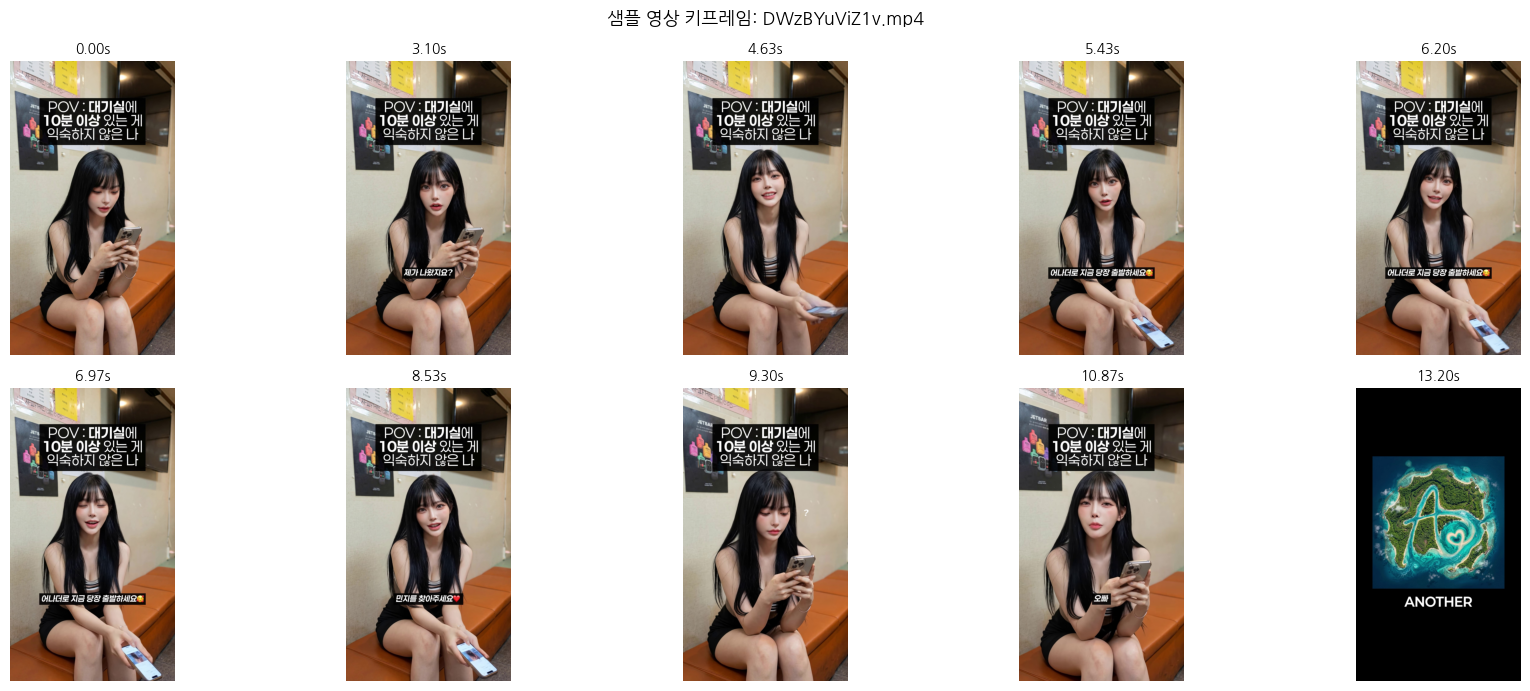

In [13]:
if all_frames:
    sample_video = list(all_frames.keys())[0]
    sample_frames = all_frames[sample_video]
    n = len(sample_frames)
    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    for ax, (ts, fp) in zip(axes.flat, sample_frames[:10]):
        ax.imshow(Image.open(fp)); ax.set_title(f'{ts:.2f}s', fontsize=10); ax.axis('off')
    for ax in axes.flat[n:]: ax.axis('off')
    plt.suptitle(f'샘플 영상 키프레임: {Path(sample_video).name}', fontsize=13)
    plt.tight_layout(); plt.show()

## 5️⃣ Few-shot 학습 데이터셋 구성
AI 영상 vs 실제 영상의 7가지 판별 규칙 + 3개 판정 예시

In [14]:
AI_VIDEO_RUBRIC = {
    'temporal_artifacts': {
        '이름': '시간적 일관성 오류',
        '설명': '프레임 간 객체/배경이 미묘하게 모핑, 손가락/머리카락 개수 변함',
        '가중치': 0.22
    },
    'physics_violation': {
        '이름': '물리 법칙 위반',
        '설명': '그림자 방향이 광원과 불일치, 반사 싱크 오류, 액체/연기 부자연스러움',
        '가중치': 0.18
    },
    'anatomy_defects': {
        '이름': '해부학적 결함',
        '설명': '손가락 6개 이상, 치아 비대칭, 귀/눈 비정상',
        '가중치': 0.20
    },
    'texture_smoothness': {
        '이름': '비정상적 텍스처 매끄러움',
        '설명': '피부/옷 과도하게 매끈, 모공 디테일 부재',
        '가중치': 0.12
    },
    'background_warping': {
        '이름': '배경/텍스트 왜곡',
        '설명': '간판 글자가 읽을 수 없는 기호, 건물 선 휘어짐',
        '가중치': 0.13
    },
    'motion_blur': {
        '이름': '비현실적 모션블러',
        '설명': '카메라 움직임과 모션블러 방향 불일치',
        '가중치': 0.08
    },
    'lighting_incoherence': {
        '이름': '조명 비일관성',
        '설명': '얼굴 좌우 광원 다름, 그림자 부드러움 불일치',
        '가중치': 0.07
    }
}

FEW_SHOT_EXAMPLES = """
[예시 1] 판정: AI 생성 (신뢰도 92%)
 - 근거: (1) 3초대 손가락 6개(해부학), (2) 배경 간판 무작위 기호(배경 왜곡), (3) 프레임 5→6 귀걸이 형태 변형(시간적 일관성).

[예시 2] 판정: 실제 영상 (AI 신뢰도 12%)
 - 근거: (1) 피부 모공·주름 디테일 자연스러움, (2) 배경 텍스트 선명, (3) 모션블러가 카메라 패닝과 정확히 일치.

[예시 3] 판정: AI 생성 (신뢰도 81%)
 - 근거: (1) 물 반사 좌우 비대칭(물리 위반), (2) 군중 얼굴 뭉개짐 반복(배경 왜곡), (3) 머리카락 끝 생성/소멸 반복(시간적 일관성).
"""

## 6️⃣ LMM 기반 AI 영상 탐지 + XAI 추론

In [15]:
def build_detection_prompt():
    rubric_text = '\n'.join([
        f"- **{v['이름']}** (가중치 {v['가중치']}): {v['설명']}"
        for k, v in AI_VIDEO_RUBRIC.items()
    ])
    return f"""당신은 AI 생성 비디오를 탐지하는 포렌식 전문가입니다.
영상(또는 키프레임 시퀀스)을 프레임 단위로 면밀히 관찰하고 AI 생성 가능성을 판정하세요.

## 탐지 기준 (Rubric)
{rubric_text}

## Few-shot 참고 예시
{FEW_SHOT_EXAMPLES}

## 출력 형식 (valid JSON 하나만, 다른 텍스트 금지)
{{
  "ai_probability": 0~100 정수,
  "verdict": "AI_GENERATED" | "LIKELY_AI" | "UNCERTAIN" | "LIKELY_REAL" | "REAL",
  "summary": "한 문장 요약",
  "evidence": [
    {{
      "category": "temporal_artifacts | physics_violation | ...",
      "frame_index": 0부터의 정수,
      "timestamp_sec": 초,
      "region": {{"x":0~1,"y":0~1,"w":0~1,"h":0~1}},
      "severity": "high|mid|low",
      "description": "구체적 관찰 (1~2문장)"
    }}
  ],
  "counter_evidence": ["반대 증거 0~3개"],
  "final_reasoning": "종합 추론 3~5문장"
}}

## 규칙
- ai_probability 75 이상이면 verdict는 AI_GENERATED 또는 LIKELY_AI
- evidence는 구체적으로 (애매한 표현 금지)
- JSON 외 다른 텍스트 금지
"""

DETECTION_PROMPT = build_detection_prompt()

In [ ]:
# (기존 Gemini 분석 셀에서 이 부분만 교체)

import re, json as _json, time

def _parse_json(text):
    text = re.sub(r'^```(json)?', '', text.strip())
    text = re.sub(r'```$', '', text.strip())
    m = re.search(r'\{[\s\S]*\}', text)
    if not m: raise ValueError('JSON 블록 없음')
    return _json.loads(m.group(0))

def analyze_video_with_gemini(video_path, frame_paths):
    content = [DETECTION_PROMPT, '\n---\n키프레임(순서대로 frame_index=0,1,2,...):\n']
    for i, (ts, fp) in enumerate(frame_paths):
        content.append(f'[frame_index={i}, t={ts:.2f}s]')
        content.append(Image.open(fp))
    try:
        uploaded = genai.upload_file(str(video_path))
        for _ in range(20):
            f = genai.get_file(uploaded.name)
            if f.state.name == 'ACTIVE': break
            time.sleep(2)
        content.insert(1, '\n[영상 파일 첨부됨]\n')
        content.insert(2, uploaded)
    except Exception as e:
        print(f'  (영상 업로드 실패, 프레임만 사용: {e})')
    response = model.generate_content(content, request_options={'timeout': 180})
    return _parse_json(response.text)


results = {}

# (1) 워터마크로 이미 AI 확정된 영상 - Gemini 스킵하고 결과에 바로 기록
for vp in ai_video_paths:
    results[vp] = {
        "ai_probability": 100,
        "verdict": "AI (워터마크 검출)",
        "source": "watermark",
        "methods_triggered": all_verdicts[vp]["methods_triggered"],
    }
    print(f'⏭️  Gemini 스킵 (워터마크): {Path(vp).name} → {all_verdicts[vp]["methods_triggered"]}')

# (2) 워터마크 통과한 영상만 Gemini 분석
for vp, frames in all_frames_for_gemini.items():
    print(f'🔎 Gemini 분석 중: {Path(vp).name}')
    try:
        r = analyze_video_with_gemini(vp, frames)
        r["source"] = "gemini"
        results[vp] = r
        print(f'  → AI 확률 {r["ai_probability"]}% | {r["verdict"]}')
    except Exception as e:
        print(f'  ❌ 실패: {e}')
        results[vp] = {'error': str(e), 'source': 'gemini'}
    time.sleep(1)

(OUTPUT_DIR / 'detection_results.json').write_text(
    _json.dumps({str(k): v for k, v in results.items()}, ensure_ascii=False, indent=2),
    encoding='utf-8'
)

print(f"\n✅ 전체 완료: 워터마크 {len(ai_video_paths)}개 + Gemini {len(clean_video_paths)}개 = 총 {len(results)}개")

🔎 Gemini 분석 중: DWzBYuViZ1v.mp4
  → AI 확률 95% | AI_GENERATED
🔎 Gemini 분석 중: DW9J3eDgbsh.mp4
  → AI 확률 95% | AI_GENERATED
🔎 Gemini 분석 중: DXB0bwtiUV9.mp4
  → AI 확률 95% | AI_GENERATED
🔎 Gemini 분석 중: DXHhIhEifBP.mp4
  → AI 확률 88% | AI_GENERATED
🔎 Gemini 분석 중: DW38xgcCVln.mp4
  → AI 확률 88% | AI_GENERATED
🔎 Gemini 분석 중: DXOMFjxiTA3.mp4
  → AI 확률 95% | AI_GENERATED
🔎 Gemini 분석 중: DXO_GzTCRIK.mp4
  → AI 확률 95% | AI_GENERATED
🔎 Gemini 분석 중: DXWKYjQib-z.mp4
  → AI 확률 95% | AI_GENERATED
🔎 Gemini 분석 중: DXI6BG0CSHy.mp4
  → AI 확률 95% | AI_GENERATED
🔎 Gemini 분석 중: DWEeptIDwJT.mp4
  → AI 확률 95% | AI_GENERATED
🔎 Gemini 분석 중: DUZlBe6Ekkr.mp4
  → AI 확률 95% | AI_GENERATED
🔎 Gemini 분석 중: DLRWOpnPfVX.mp4


ERROR:tornado.access:503 POST /v1beta/models/gemini-3.1-flash-lite-preview:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 20848.80ms


  → AI 확률 88% | AI_GENERATED
🔎 Gemini 분석 중: DXO2CzaAIWR.mp4
  → AI 확률 95% | AI_GENERATED
🔎 Gemini 분석 중: DVxMvXcifmE.mp4
  → AI 확률 98% | AI_GENERATED
🔎 Gemini 분석 중: DQJa9D3CZrc.mp4
  → AI 확률 95% | AI_GENERATED
🔎 Gemini 분석 중: DWLuSyIkhMV.mp4
  → AI 확률 95% | AI_GENERATED
🔎 Gemini 분석 중: DVzVq5ND3lg.mp4
  → AI 확률 98% | AI_GENERATED
🔎 Gemini 분석 중: DW_HNH7gFVr.mp4
  → AI 확률 98% | AI_GENERATED
🔎 Gemini 분석 중: DSv0eT5Agk-.mp4
  → AI 확률 95% | AI_GENERATED
🔎 Gemini 분석 중: DRYfSidEYX5.mp4
  → AI 확률 95% | AI_GENERATED
🔎 Gemini 분석 중: DWks41KCQLf.mp4
  → AI 확률 95% | AI_GENERATED
🔎 Gemini 분석 중: DUiDSdWCNMX.mp4
  → AI 확률 98% | AI_GENERATED
🔎 Gemini 분석 중: DUN9-ZGEbHh.mp4
  → AI 확률 95% | AI_GENERATED
🔎 Gemini 분석 중: DXeZLPRjl5k.mp4
  → AI 확률 88% | AI_GENERATED
🔎 Gemini 분석 중: DXdotCVjh3Y.mp4
  → AI 확률 88% | AI_GENERATED
🔎 Gemini 분석 중: DXoT_sEDuGm.mp4
  → AI 확률 88% | AI_GENERATED
🔎 Gemini 분석 중: DXoTcfPjs7P.mp4
  → AI 확률 88% | AI_GENERATED
🔎 Gemini 분석 중: DXdOvulDhSS.mp4
  → AI 확률 88% | AI_GENERATED
🔎 Gemini 분석

ERROR:tornado.access:503 POST /v1beta/models/gemini-3.1-flash-lite-preview:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 15187.51ms


  → AI 확률 88% | AI_GENERATED
🔎 Gemini 분석 중: DS3thJQCcWD.mp4
  → AI 확률 95% | AI_GENERATED
🔎 Gemini 분석 중: DV6JvL5E-Eb.mp4
  → AI 확률 96% | AI_GENERATED
🔎 Gemini 분석 중: DXES5ivj1Ee.mp4
  → AI 확률 95% | AI_GENERATED
🔎 Gemini 분석 중: DQfINMOESwD.mp4


...

  → AI 확률 95% | AI_GENERATED
🔎 Gemini 분석 중: DWdztGKjd3K.mp4
  → AI 확률 98% | AI_GENERATED
🔎 Gemini 분석 중: DXCGiTrD2hA.mp4


ERROR:tornado.access:503 POST /v1beta/models/gemini-3.1-flash-lite-preview:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 18883.59ms


  → AI 확률 95% | AI_GENERATED
🔎 Gemini 분석 중: DUSzr3pkT-b.mp4


ERROR:tornado.access:503 POST /v1beta/models/gemini-3.1-flash-lite-preview:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 14520.15ms


  → AI 확률 95% | AI_GENERATED
🔎 Gemini 분석 중: DTuqBWzEUQQ.mp4
  → AI 확률 88% | AI_GENERATED
🔎 Gemini 분석 중: DRX1v7fE4vH.mp4
  → AI 확률 95% | AI_GENERATED
🔎 Gemini 분석 중: DV589YvDFNC.mp4
  → AI 확률 88% | AI_GENERATED
🔎 Gemini 분석 중: DTfeHKrieaC.mp4
  → AI 확률 88% | AI_GENERATED
🔎 Gemini 분석 중: DMh2ksdyr1_.mp4
  → AI 확률 88% | AI_GENERATED
🔎 Gemini 분석 중: DWM4PSAgDlZ.mp4
  → AI 확률 88% | AI_GENERATED
🔎 Gemini 분석 중: DNEI4GkTO71.mp4
  ❌ 실패: HTTPConnectionPool(host='localhost', port=46883): Read timed out. (read timeout=180.0)
🔎 Gemini 분석 중: DTzdz9FklgB.mp4


In [ ]:
SEVERITY_COLOR = {'high': '#E53935', 'mid': '#FB8C00', 'low': '#FDD835'}
CATEGORY_KR = {k: v['이름'] for k, v in AI_VIDEO_RUBRIC.items()}

def visualize_evidence(video_path, frame_paths, result, save_path=None):
    if 'error' in result: return
    evidences = result.get('evidence', [])
    by_frame = {}
    for e in evidences:
        idx = min(int(e.get('frame_index', 0)), len(frame_paths)-1)
        by_frame.setdefault(idx, []).append(e)

    highlighted_indices = sorted(by_frame.keys())
    n = max(len(highlighted_indices), 1)
    cols = min(n, 3); rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6.5*cols, 5.5*rows))
    axes = np.atleast_1d(axes).flatten()

    for ax, fi in zip(axes, highlighted_indices):
        ts, fp = frame_paths[fi]
        img = Image.open(fp); w, h = img.size
        ax.imshow(img)
        for e in by_frame[fi]:
            r = e.get('region', {})
            x = float(r.get('x', 0.1)) * w
            y = float(r.get('y', 0.1)) * h
            rw = float(r.get('w', 0.3)) * w
            rh = float(r.get('h', 0.3)) * h
            color = SEVERITY_COLOR.get(e.get('severity', 'mid'), '#FB8C00')
            rect = patches.Rectangle((x, y), rw, rh, linewidth=3.2,
                                    edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            label = CATEGORY_KR.get(e.get('category', ''), '')
            ax.text(x, max(y-8, 12), f"● {label}", color='white', fontsize=9, weight='bold',
                    bbox=dict(facecolor=color, alpha=0.9, pad=2, edgecolor='none'))
        ax.set_title(f'frame#{fi} · t={ts:.2f}s', fontsize=10)
        ax.axis('off')
    for ax in axes[len(highlighted_indices):]: ax.axis('off')

    title = f"[{Path(video_path).name}]  AI 확률 {result['ai_probability']}% — {result['verdict']}"
    plt.suptitle(title, fontsize=14, weight='bold')
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()

for vp, frames in all_frames.items():
    r = results.get(vp, {})
    out = OUTPUT_DIR / f"xai_{Path(vp).stem}.png"
    visualize_evidence(vp, frames, r, save_path=out)

## 8️⃣ 종합 보고서 — "왜 이것이 75% 이상 AI 영상인가?"

In [ ]:
VERDICT_EMOJI = {
    'AI_GENERATED': '🚨', 'LIKELY_AI': '⚠️',
    'UNCERTAIN': '❓', 'LIKELY_REAL': '✅', 'REAL': '✅'
}
SEV_BADGE = {'high': '🔴 HIGH', 'mid': '🟠 MID', 'low': '🟡 LOW'}

def build_report_md(video_path, frames, result):
    if 'error' in result:
        return f"### ❌ {Path(video_path).name}\n오류: `{result['error']}`"

    prob = result['ai_probability']
    verdict = result['verdict']
    emoji = VERDICT_EMOJI.get(verdict, '')
    is_ai_flagged = prob >= 75

    lines = [f'## {emoji} {Path(video_path).name}', '']
    lines.append('| 항목 | 값 |')
    lines.append('|---|---|')
    lines.append(f'| AI 생성 확률 | **{prob}%** {"🚨 (75% 초과)" if is_ai_flagged else ""} |')
    lines.append(f'| 판정 | {verdict} |')
    lines.append(f'| 요약 | {result.get("summary", "-")} |')
    lines.append('')

    if is_ai_flagged:
        lines.append(f'### 🔎 왜 이것이 {prob}% 확률로 AI 영상인가? — 근거\n')
    else:
        lines.append('### 🔎 관찰된 근거\n')

    for i, e in enumerate(result.get('evidence', []), 1):
        cat = CATEGORY_KR.get(e.get('category',''), '?')
        sev = SEV_BADGE.get(e.get('severity','mid'), '')
        ts = e.get('timestamp_sec', 0)
        fi = e.get('frame_index', 0)
        desc = e.get('description', '')
        lines.append(f'**{i}. {cat}** · {sev} · `frame#{fi}` `t={ts:.2f}s`')
        lines.append(f'> {desc}')
        lines.append('')

    ce = result.get('counter_evidence', [])
    if ce:
        lines.append('### ↩️ 반대 증거')
        for c in ce: lines.append(f'- {c}')
        lines.append('')

    lines.append('### 🧠 최종 추론')
    lines.append(result.get('final_reasoning', '-'))
    lines.append('\n---\n')
    return '\n'.join(lines)

full_md = ['# 🎬 Instagram AI 영상 탐지 보고서\n']
full_md.append(f'- 분석 영상 수: **{len(results)}**')
flagged = [v for v,r in results.items() if isinstance(r, dict) and r.get('ai_probability',0) >= 75]
full_md.append(f'- 75% 이상 AI 의심: **{len(flagged)}**\n---\n')

for vp, frames in all_frames.items():
    full_md.append(build_report_md(vp, frames, results.get(vp, {})))

report_text = '\n'.join(full_md)
(OUTPUT_DIR / 'report.md').write_text(report_text, encoding='utf-8')
display(Markdown(report_text))

## 9️⃣ 결과 다운로드
- detection_results.json · report.md · xai_*.png

In [ ]:
import shutil
archive = '/content/ai_video_detection_outputs'
shutil.make_archive(archive, 'zip', OUTPUT_DIR)
from google.colab import files
files.download(archive + '.zip')

## 🧪 모델 개선 팁
1. Temperature 낮추기 (0.0 ~ 0.2)
2. 앙상블 (Gemini Pro + Flash)
3. Self-consistency (3회 호출 → 중앙값)
4. Rubric 확장 (Sora, Veo, Runway 시그니처 추가)
5. Fine-tuning (CLIP/ViT 분류기와 앙상블)
6. 캘리브레이션 (isotonic / Platt scaling)